In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict, Optional
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset

/Users/milesmarkey/projects/playground/sae_trainer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [85]:
root = Path.cwd().resolve()
root = root.parent
sys.path.insert(0, str(root))

from sae_trainer.dataset_utils import make_collate_fn, TextDataset, get_data_loaders
from sae_trainer.train_utils import train_sae
from sae_trainer.eval_utils import evaluate_sae, visualize_sae
from sae_trainer.model_utils import SparseAutoencoder

In [4]:
class ActivationCollector:
    """
    Collects activations from selected Qwen2 layers:
      - residual_out: output of decoder layer (hidden_states)
      - mlp_down_out: output of layer.mlp.down_proj
    """
    def __init__(
        self,
        model: torch.nn.Module,
        layer_ids: List[int],
        capture_residual: bool = True,
        capture_mlp_down: bool = False,
        to_cpu: bool = True,
        dtype: torch.dtype = torch.float32,
    ):
        self.model = model
        self.layer_ids = layer_ids
        self.capture_residual = capture_residual
        self.capture_mlp_down = capture_mlp_down
        self.to_cpu = to_cpu
        self.dtype = dtype

        self.hooks = []
        self.buffer: Dict[str, Dict[int, torch.Tensor]] = {
            "residual_out": {},
            "mlp_down_out": {},
        }

    def _clear_batch_buffer(self):
        self.buffer["residual_out"].clear()
        self.buffer["mlp_down_out"].clear()

    @staticmethod
    def _hidden_from_output(output):
        # Some HF modules return tuple; hidden_states is first item
        return output[0] if isinstance(output, tuple) else output

    def _make_block_hook(self, layer_idx: int):
        def hook(module, inputs, output):
            hs = self._hidden_from_output(output)
            t = hs.detach().to(self.dtype)
            if self.to_cpu:
                t = t.cpu()
            self.buffer["residual_out"][layer_idx] = t
        return hook

    def _make_mlp_down_hook(self, layer_idx: int):
        def hook(module, inputs, output):
            t = output.detach().to(self.dtype)
            if self.to_cpu:
                t = t.cpu()
            self.buffer["mlp_down_out"][layer_idx] = t
        return hook

    def register(self):
        self.remove()
        for i in self.layer_ids:
            layer = self.model.model.layers[i]
            if self.capture_residual:
                self.hooks.append(layer.register_forward_hook(self._make_block_hook(i)))
            if self.capture_mlp_down:
                self.hooks.append(layer.mlp.down_proj.register_forward_hook(self._make_mlp_down_hook(i)))

    def remove(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def collect_batch(self, model_inputs: Dict[str, torch.Tensor], model: Optional[torch.nn.Module] = None):
        """
        Runs one forward pass and returns flattened activations per layer:
          out[name][layer] -> [batch*seq, d_model]
        """
        if model is None:
            model = self.model

        self._clear_batch_buffer()
        with torch.no_grad():
            _ = model(**model_inputs)

        out = {"residual_out": {}, "mlp_down_out": {}}
        for name in out.keys():
            for layer_idx, x in self.buffer[name].items():
                # [B, S, D] -> [B*S, D]
                out[name][layer_idx] = x.reshape(-1, x.shape[-1])
        return out

In [5]:
# --- Setup model/tokenizer ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "Qwen/Qwen2-0.5B-Instruct"  # replace if needed

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((

In [6]:
# --- Example text corpus ---
texts = [
    "The Eiffel Tower is in Paris.",
    "A sparse autoencoder can discover interpretable features.",
    "Neural networks represent concepts across many layers.",
    "Attention heads may specialize in different linguistic patterns.",
    "Residual stream activations are useful for mechanistic interpretability.",
] * 200  # repeat just for demo

#dataset = TextDataset(texts)
#texts = []
#ds = load_dataset("wikitext", "wikitext-103-raw-v1", split="train", streaming=True)

#ds = ds.shuffle(seed=42)
#ds = ds.with_format("torch")
#for row in ds:
#    texts.append(row["text"])
dataset = TextDataset(texts)
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=make_collate_fn(tokenizer, max_length=128),
)

In [8]:
# --- Register collector ---
target_layers = [12, 16, 20, 23]
collector = ActivationCollector(
    model=model,
    layer_ids=target_layers,
    capture_residual=True,
    capture_mlp_down=False,   # set True if you want both
    to_cpu=True,
    dtype=torch.float32,
)
collector.register()

In [9]:
# --- Dataloader loop to accumulate activations ---
# Stores per-layer chunks, then concatenates at end.
accum = {"residual_out": {i: [] for i in target_layers},
         "mlp_down_out": {i: [] for i in target_layers}}

max_batches = 50  # increase for more data
for step, batch in enumerate(loader):
    if step >= max_batches:
        break

    batch = {k: v.to(device) for k, v in batch.items()}
    acts = collector.collect_batch(batch)

    # Optional: remove pad tokens before append
    # (for now we keep all tokens; filtering can be done later)

    for name in ["residual_out", "mlp_down_out"]:
        for i, x in acts[name].items():
            accum[name][i].append(x)

# concat
for name in ["residual_out", "mlp_down_out"]:
    for i in target_layers:
        if len(accum[name][i]) > 0:
            accum[name][i] = torch.cat(accum[name][i], dim=0)
        else:
            accum[name][i] = None

collector.remove()

for i in target_layers:
    x = accum["residual_out"][i]
    print(f"Layer {i} residual:", None if x is None else tuple(x.shape))

Layer 12 residual: (4800, 896)
Layer 16 residual: (4800, 896)
Layer 20 residual: (4800, 896)
Layer 23 residual: (4800, 896)


In [ ]:
def training_wrapper(accum, layer_idx, device, mass_frac_threshold, save_filename=None):

    train_loader, val_loader, d_in = get_data_loaders(accum, layer_idx)
    # ---- Model + optimizer ----
    expansion = 8                 # 4-16 are common starting points
    d_latent = d_in * expansion # d_in = 3584, so this should be in ~[14k, 60k] (14336-57344)

    sae = SparseAutoencoder(d_in=d_in, d_latent=d_latent).to(device)
    opt = torch.optim.AdamW(sae.parameters(), lr=3e-4, weight_decay=1e-4)

    # Sparsity strength: tune this. Start small.
    lambda_l1 = 1e-4

    # Optional: LR scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)

    sae, history = train_sae(sae, train_loader, val_loader, opt, scheduler, device, lambda_l1, mass_frac_threshold=mass_frac_threshold)

    if save_filename:
        # ---- Save checkpoint ----
        ckpt = {
            "model_state": sae.state_dict(),
            "d_in": d_in,
            "d_latent": d_latent,
            "lambda_l1": lambda_l1,
            "history": history,
        }
        torch.save(ckpt, save_filename)
        print(f"Saved: {save_filename}")

    return sae, history, train_loader, val_loader

In [97]:
# 0.005 - 0.05
mass_frac_threshold=0.001

Epoch 01 | train loss 186.863274 (recon 186.863197, l1 0.810178) | val loss 148.355392 (recon 148.355301, l1 0.845769) | val active 14.1
Epoch 02 | train loss 132.408966 (recon 132.408890, l1 0.803653) | val loss 116.733566 (recon 116.733482, l1 0.849998) | val active 12.6
Epoch 03 | train loss 104.269711 (recon 104.269627, l1 0.829847) | val loss 83.121529 (recon 83.121445, l1 0.861291) | val active 11.8
Epoch 04 | train loss 71.082798 (recon 71.082718, l1 0.809160) | val loss 60.330540 (recon 60.330452, l1 0.879544) | val active 12.9
Epoch 05 | train loss 51.763039 (recon 51.762955, l1 0.849259) | val loss 39.942432 (recon 39.942341, l1 0.903570) | val active 15.2
Epoch 06 | train loss 35.485245 (recon 35.485156, l1 0.892508) | val loss 25.349457 (recon 25.349363, l1 0.931539) | val active 18.4
Epoch 07 | train loss 21.311140 (recon 21.311051, l1 0.890339) | val loss 14.153352 (recon 14.153255, l1 0.961235) | val active 20.1
Epoch 08 | train loss 11.739132 (recon 11.739038, l1 0.9336

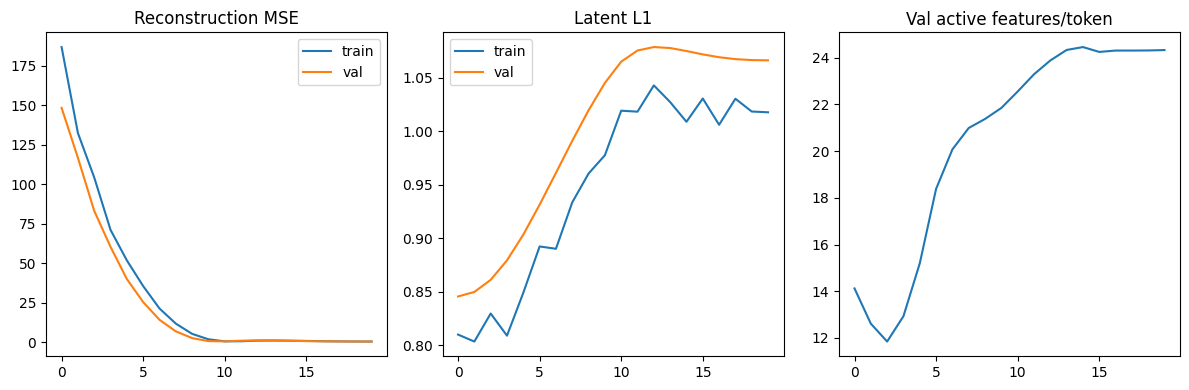

In [98]:
sae_12, history_12, train_loader_12, _ = training_wrapper(accum, 12, device, mass_frac_threshold)

Epoch 01 | train loss 195.862282 (recon 195.862190, l1 0.894632) | val loss 154.077560 (recon 154.077469, l1 0.925129) | val active 12.3
Epoch 02 | train loss 138.380905 (recon 138.380814, l1 0.891322) | val loss 120.414749 (recon 120.414658, l1 0.932519) | val active 11.4
Epoch 03 | train loss 105.241478 (recon 105.241386, l1 0.902745) | val loss 85.154236 (recon 85.154144, l1 0.948187) | val active 10.8
Epoch 04 | train loss 77.459862 (recon 77.459766, l1 0.939356) | val loss 60.544777 (recon 60.544682, l1 0.970822) | val active 11.2
Epoch 05 | train loss 52.128660 (recon 52.128565, l1 0.943248) | val loss 39.187733 (recon 39.187634, l1 0.997836) | val active 13.2
Epoch 06 | train loss 32.265574 (recon 32.265480, l1 0.944414) | val loss 23.794306 (recon 23.794203, l1 1.028652) | val active 15.6
Epoch 07 | train loss 19.363769 (recon 19.363671, l1 0.977228) | val loss 12.690657 (recon 12.690551, l1 1.061919) | val active 17.7
Epoch 08 | train loss 10.263593 (recon 10.263490, l1 1.0232

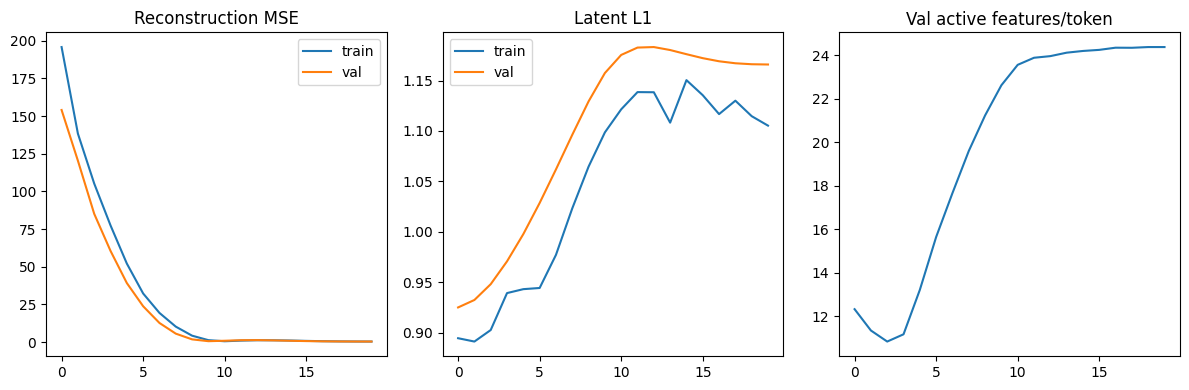

In [101]:
sae_16, history_16, train_loader_16, _ = training_wrapper(accum, 16, device, mass_frac_threshold)

Epoch 01 | train loss 194.516785 (recon 194.516685, l1 1.024878) | val loss 150.745102 (recon 150.744995, l1 1.058923) | val active 6.4
Epoch 02 | train loss 135.786980 (recon 135.786880, l1 1.028249) | val loss 117.312103 (recon 117.311996, l1 1.070475) | val active 5.6
Epoch 03 | train loss 99.303829 (recon 99.303726, l1 1.019660) | val loss 81.359764 (recon 81.359657, l1 1.092592) | val active 4.6
Epoch 04 | train loss 72.119678 (recon 72.119574, l1 1.064888) | val loss 57.522671 (recon 57.522560, l1 1.122519) | val active 5.4
Epoch 05 | train loss 49.204695 (recon 49.204588, l1 1.084758) | val loss 36.636028 (recon 36.635914, l1 1.156512) | val active 6.7
Epoch 06 | train loss 31.190632 (recon 31.190519, l1 1.119370) | val loss 21.729174 (recon 21.729053, l1 1.194292) | val active 9.3
Epoch 07 | train loss 18.024369 (recon 18.024251, l1 1.174031) | val loss 11.099833 (recon 11.099710, l1 1.234467) | val active 11.4
Epoch 08 | train loss 9.223115 (recon 9.222993, l1 1.220304) | val 

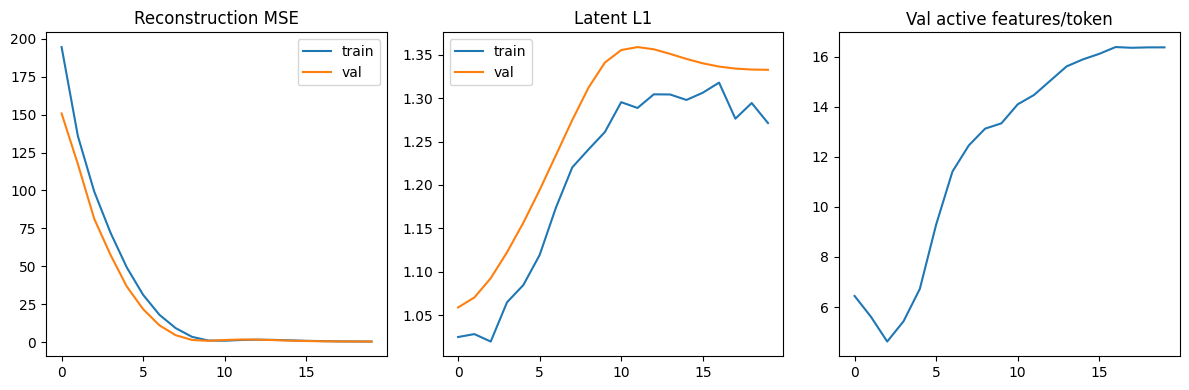

In [102]:
sae_20, history_20, train_loader_20, _ = training_wrapper(accum, 20, device, mass_frac_threshold)

Epoch 01 | train loss 8.170267 (recon 8.170215, l1 0.519278) | val loss 5.325395 (recon 5.325343, l1 0.520621) | val active 14.7
Epoch 02 | train loss 4.597057 (recon 4.597004, l1 0.520894) | val loss 3.097757 (recon 3.097703, l1 0.539982) | val active 16.4
Epoch 03 | train loss 2.611182 (recon 2.611127, l1 0.545235) | val loss 1.728274 (recon 1.728216, l1 0.574247) | val active 17.2
Epoch 04 | train loss 1.487262 (recon 1.487204, l1 0.581428) | val loss 1.065517 (recon 1.065455, l1 0.614611) | val active 16.9
Epoch 05 | train loss 0.956546 (recon 0.956484, l1 0.620703) | val loss 0.771144 (recon 0.771080, l1 0.641143) | val active 17.5
Epoch 06 | train loss 0.714588 (recon 0.714524, l1 0.641216) | val loss 0.592751 (recon 0.592687, l1 0.646333) | val active 19.7
Epoch 07 | train loss 0.544485 (recon 0.544421, l1 0.640396) | val loss 0.429411 (recon 0.429347, l1 0.637745) | val active 22.6
Epoch 08 | train loss 0.387219 (recon 0.387156, l1 0.630177) | val loss 0.293253 (recon 0.293191,

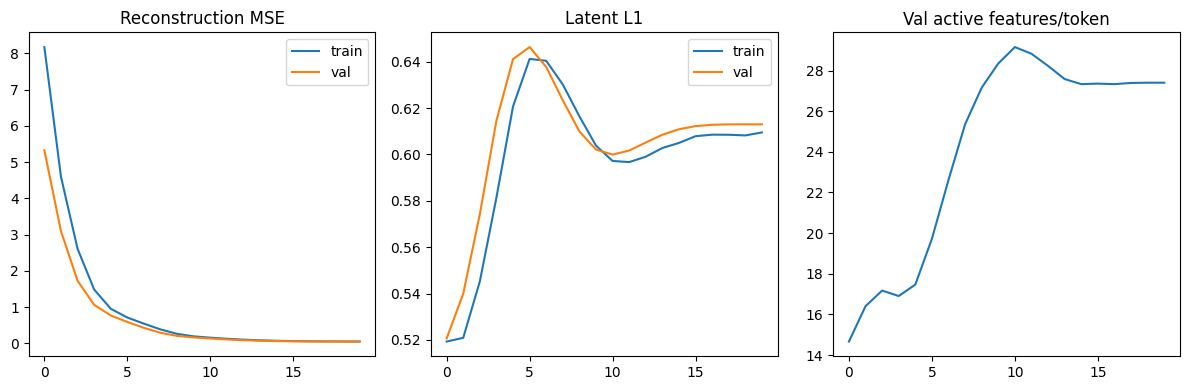

In [103]:
sae_23, history_23, train_loader_23, _ = training_wrapper(accum, 23, device, mass_frac_threshold)

In [68]:
history_12['train_l1']

[0.8157608509063721,
 0.8340848088264465,
 0.8376762568950653,
 0.8421154916286469,
 0.8839055001735687,
 0.8908824026584625,
 0.9286664426326752,
 0.9367398619651794,
 0.9827096462249756,
 1.0463970303535461,
 1.0441243052482605,
 1.0818434357643127,
 1.0496975779533386,
 1.082533597946167,
 1.0731323957443237,
 1.053151935338974,
 1.0755282044410706,
 1.0478549599647522,
 1.0470435619354248,
 1.0116769075393677]

In [99]:
metrics_12 = evaluate_sae(sae_12, train_loader_12, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True) #active_threshold=1e-6,

=== SAE Metrics ===
                             mse: 0.360651
              explained_variance: 0.997981
                   avg_l1_latent: 1.025158
   avg_active_features_per_token: 25.547363
               dead_feature_rate: 0.891323
                   usage_entropy: 6.307670
                usage_perplexity: 548.764638


In [105]:
metrics_16 = evaluate_sae(sae_16, train_loader_16, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)

=== SAE Metrics ===
                             mse: 0.348486
              explained_variance: 0.998041
                   avg_l1_latent: 1.113107
   avg_active_features_per_token: 25.388184
               dead_feature_rate: 0.872768
                   usage_entropy: 6.492839
                usage_perplexity: 660.395475


In [106]:
metrics_20 = evaluate_sae(sae_20, train_loader_20, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)

=== SAE Metrics ===
                             mse: 0.411810
              explained_variance: 0.997699
                   avg_l1_latent: 1.283337
   avg_active_features_per_token: 17.933838
               dead_feature_rate: 0.910714
                   usage_entropy: 6.172769
                usage_perplexity: 479.512072


In [107]:
metrics_23 = evaluate_sae(sae_23, train_loader_23, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)

=== SAE Metrics ===
                             mse: 0.052460
              explained_variance: 0.993511
                   avg_l1_latent: 0.607697
   avg_active_features_per_token: 27.281738
               dead_feature_rate: 0.891323
                   usage_entropy: 6.205624
                usage_perplexity: 495.527884


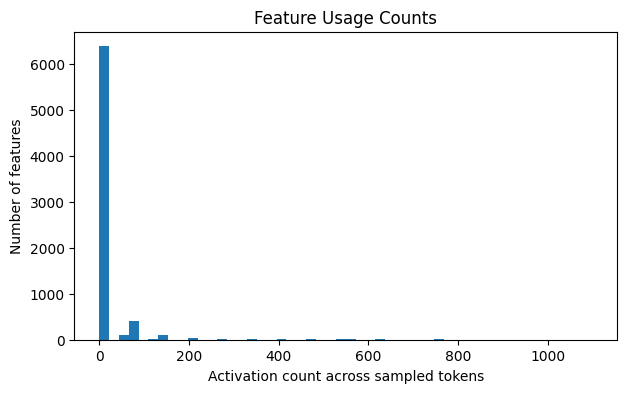

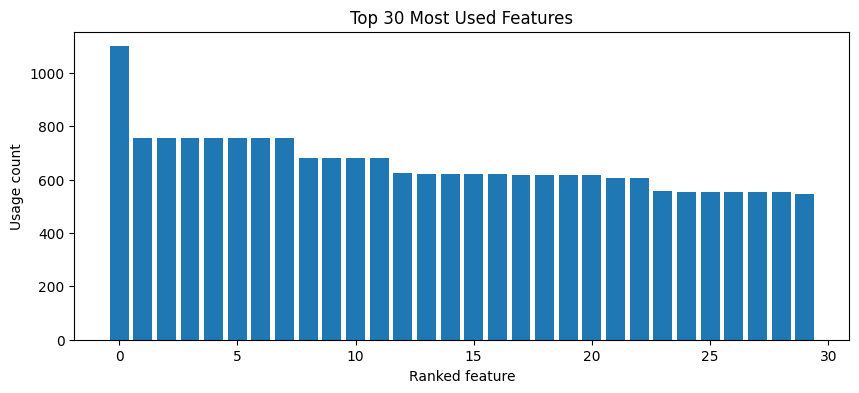

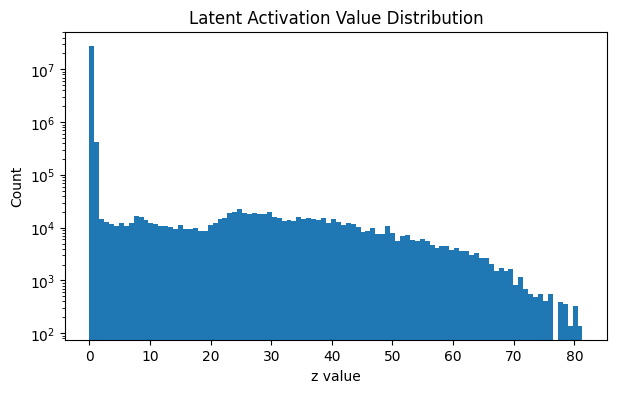

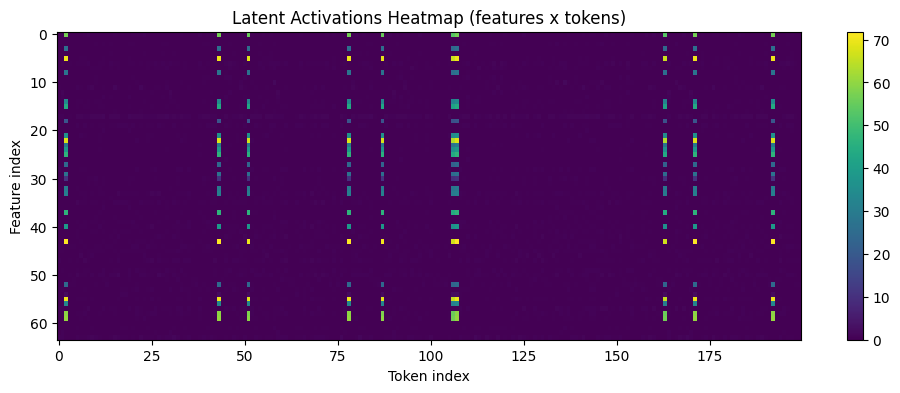

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [100]:
visualize_sae(metrics_12)

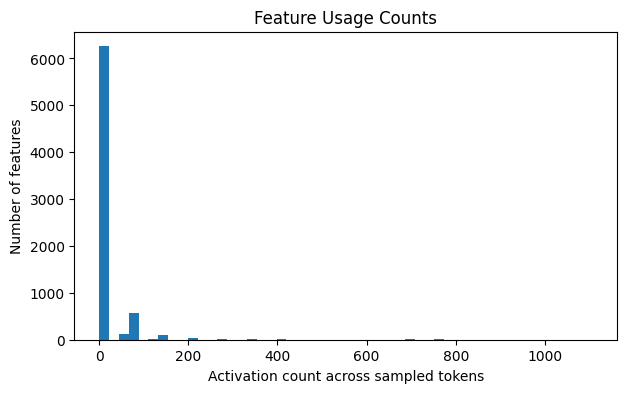

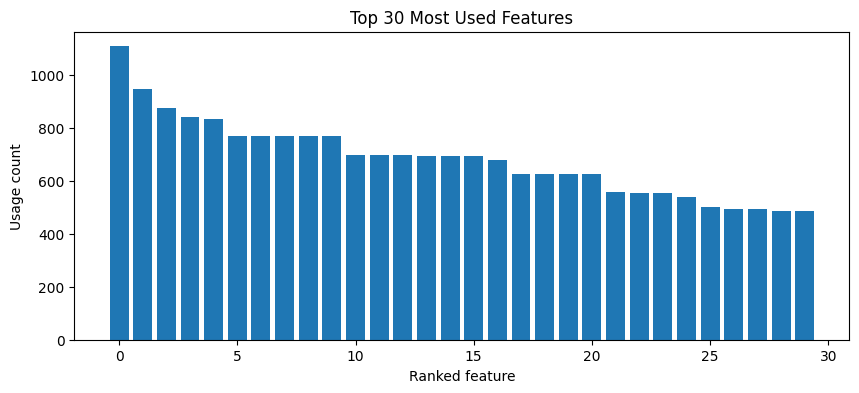

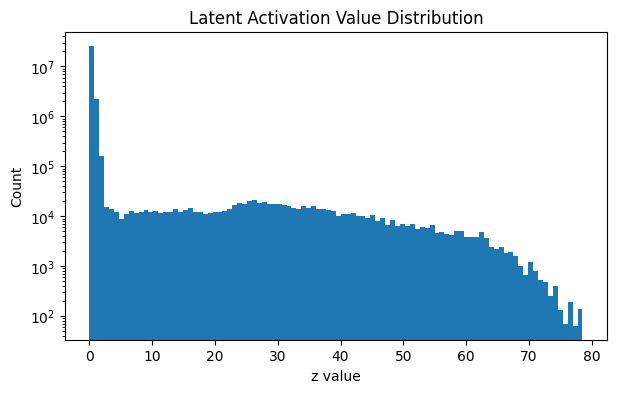

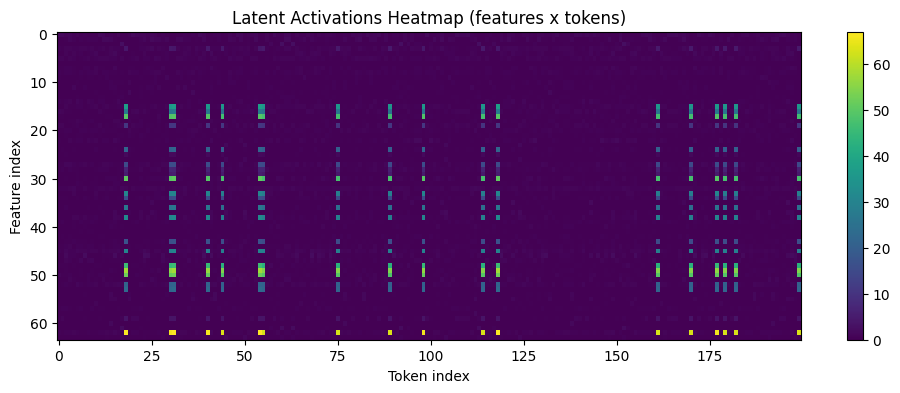

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [108]:
visualize_sae(metrics_16)

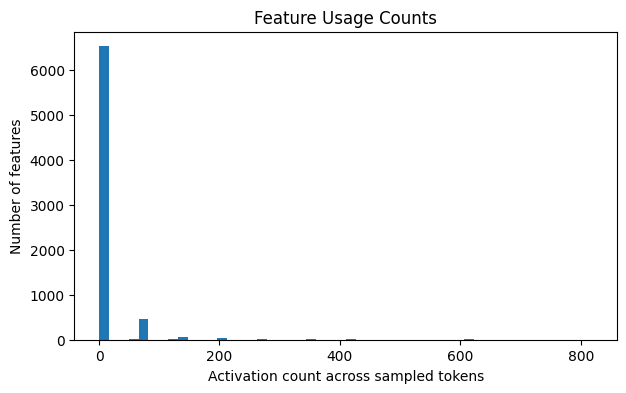

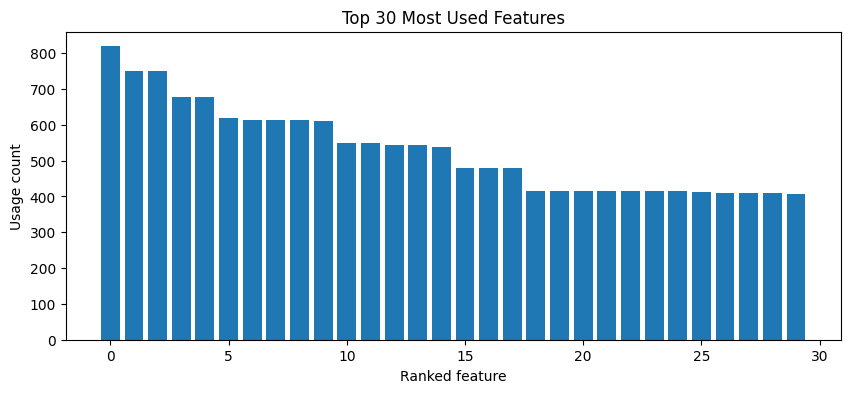

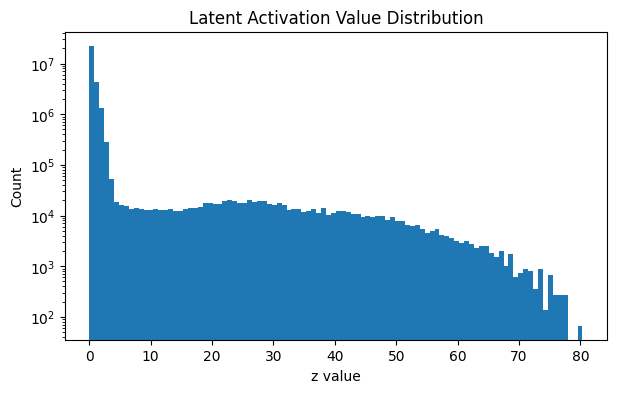

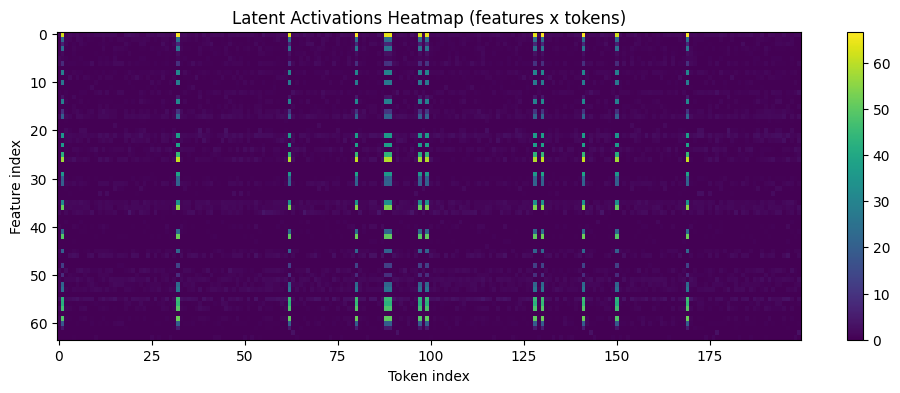

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [109]:
visualize_sae(metrics_20)

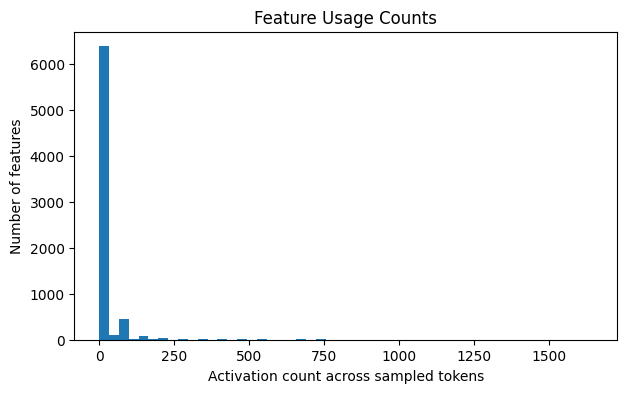

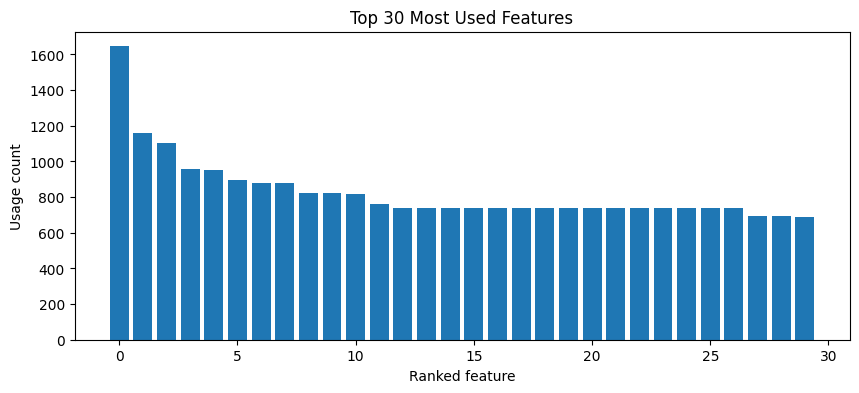

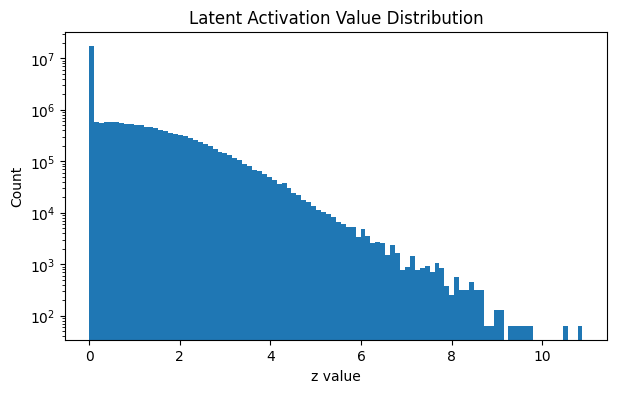

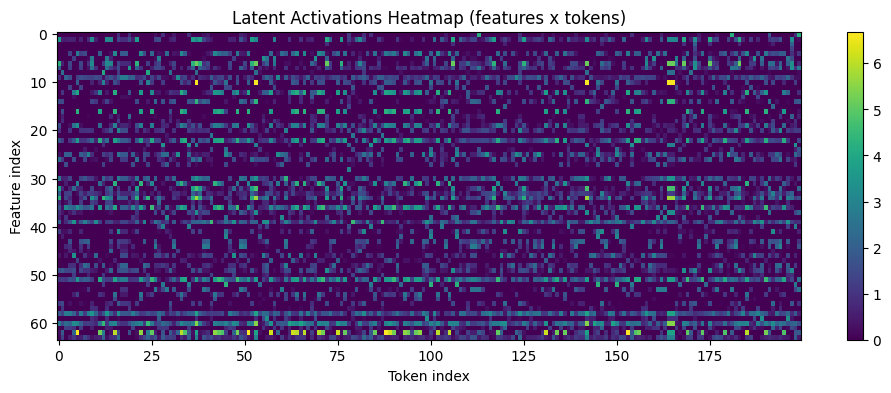

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [110]:
visualize_sae(metrics_23)

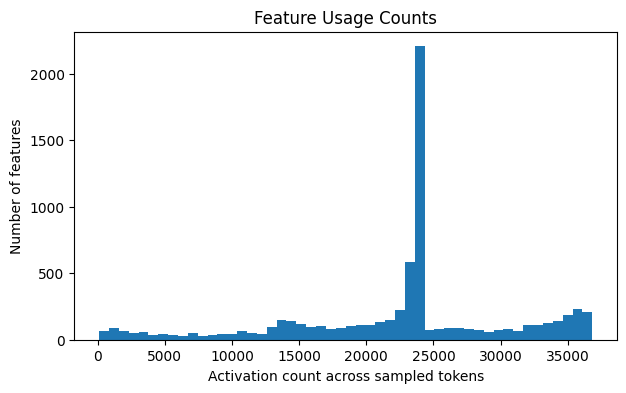

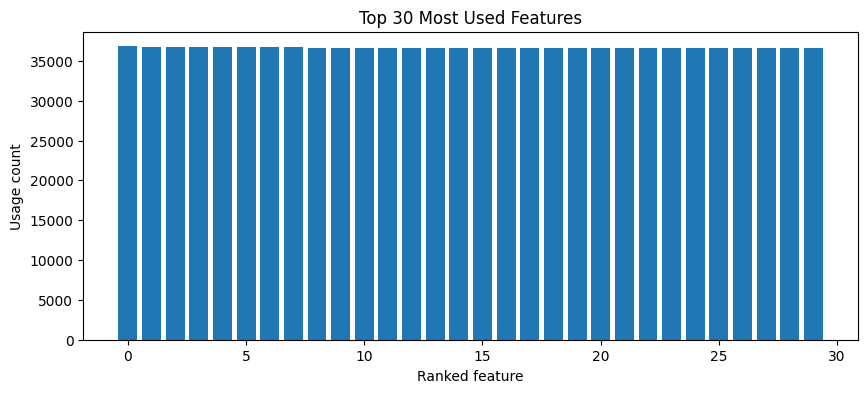

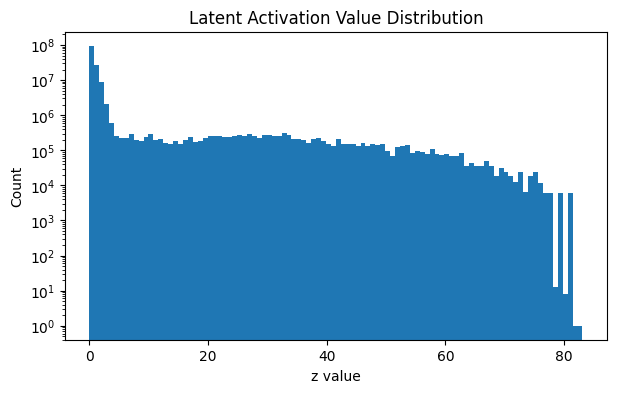

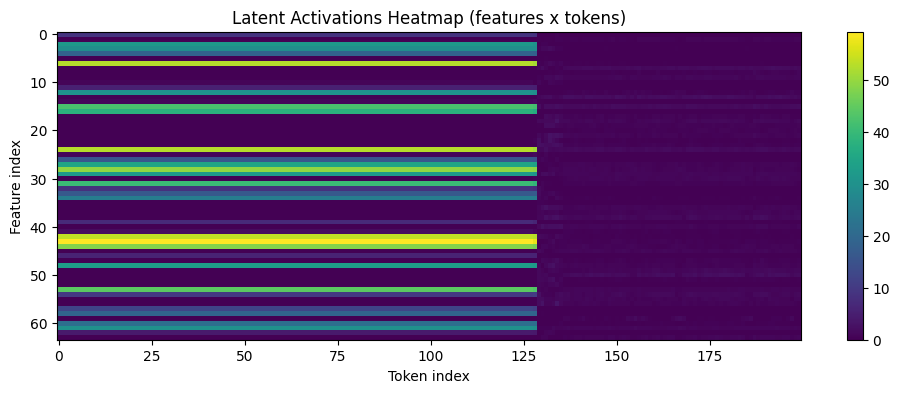

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [ ]:
# -------------------------
# 3) Visualizations
# -------------------------
usage = metrics["usage_counter"]
z_sample = metrics["z_sample"]

# Feature usage histogram
plt.figure(figsize=(7,4))
plt.hist(usage, bins=50)
plt.title("Feature Usage Counts")
plt.xlabel("Activation count across sampled tokens")
plt.ylabel("Number of features")
plt.show()

# Top most-used features
top_k = 30 # try 100
top_idx = np.argsort(-usage)[:top_k]
plt.figure(figsize=(10,4))
plt.bar(np.arange(top_k), usage[top_idx])
plt.title(f"Top {top_k} Most Used Features")
plt.xlabel("Ranked feature")
plt.ylabel("Usage count")
plt.show()

if z_sample is not None:
    # Latent activation value distribution
    plt.figure(figsize=(7,4))
    plt.hist(z_sample.flatten(), bins=100)
    plt.title("Latent Activation Value Distribution")
    plt.xlabel("z value")
    plt.ylabel("Count")
    plt.yscale("log")
    plt.show()

    # Sequence-position heatmap-like view (first 200 tokens, first 64 features)
    n_tokens = min(200, z_sample.shape[0])
    n_feats = min(64, z_sample.shape[1])
    plt.figure(figsize=(12,4))
    plt.imshow(z_sample[:n_tokens, :n_feats].T, aspect="auto", interpolation="nearest")
    plt.title("Latent Activations Heatmap (features x tokens)")
    plt.xlabel("Token index")
    plt.ylabel("Feature index")
    plt.colorbar()
    plt.show()

    # Optional UMAP projection of token latents
    if HAS_UMAP and z_sample.shape[0] > 200:
        z_for_umap = z_sample[:5000]
        reducer = umap.UMAP(n_neighbors=30, min_dist=0.05, metric="cosine", random_state=42)
        z_2d = reducer.fit_transform(z_for_umap)

        plt.figure(figsize=(6,6))
        plt.scatter(z_2d[:,0], z_2d[:,1], s=2, alpha=0.5)
        plt.title("UMAP of SAE Latent Activations")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.show()
    elif not HAS_UMAP:
        print("UMAP not installed. `pip install umap-learn` to enable latent-space plot.")

In [ ]:
# -------------------------
# 4) Optional: quick baseline comparison helper for comparing multiple SAEs
# -------------------------
def print_eval_table(rows):
    # rows: list of dicts with keys: name + metric keys
    cols = ["name","mse","explained_variance","avg_active_features_per_token","dead_feature_rate","usage_perplexity"]
    print(" | ".join(f"{c:>28}" for c in cols))
    print("-" * (31 * len(cols)))
    for r in rows:
        vals = []
        for c in cols:
            v = r[c]
            if isinstance(v, float):
                vals.append(f"{v:>28.6f}")
            else:
                vals.append(f"{str(v):>28}")
        print(" | ".join(vals))

# Example:
#rows = []
#for name, sae_model in [("sae_l1_1e-3", sae1), ("sae_l1_5e-4", sae2)]:
#    m = evaluate_sae(sae_model, x_train)
#    m["name"] = name
#    rows.append(m)
#print_eval_table(rows)

NameError: name 'sae1' is not defined